Lendo o arquivo

In [246]:
import pandas as pd
import matplotlib.pyplot as plt

arquivo = r'C:\Users\twvin\OneDrive\Área de Trabalho\Compass.UOL\Sprint02\Desafio\googleplaystore.csv'
tabela = pd.read_csv(arquivo)


print("\nInformações da tabela:")
print(tabela.info())


Informações da tabela:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None


Removendo linhas duplicadas:

In [247]:
linhas = len(tabela)
print("Número de linhas antes:", linhas)

linhas_unicas = tabela.drop_duplicates()
linhas_resto = len(linhas_unicas)
print("Número de linhas sem duplicadas:", linhas_resto)

Número de linhas antes: 10841
Número de linhas sem duplicadas: 10358


5 Apps mais populares (Gráfico de Barras):

C:\Users\twvin\AppData\Local\Temp\ipykernel_17504\3340189588.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linhas_unicas['Installs'] = coluna_instalacoes



Top 5 aplicativos mais instalados:
App
Subway Surfers                  5.000000e+09
Google Photos                   4.000000e+09
Hangouts                        4.000000e+09
Google Chrome: Fast & Secure    3.000000e+09
Google Drive                    3.000000e+09
Name: Installs, dtype: float64


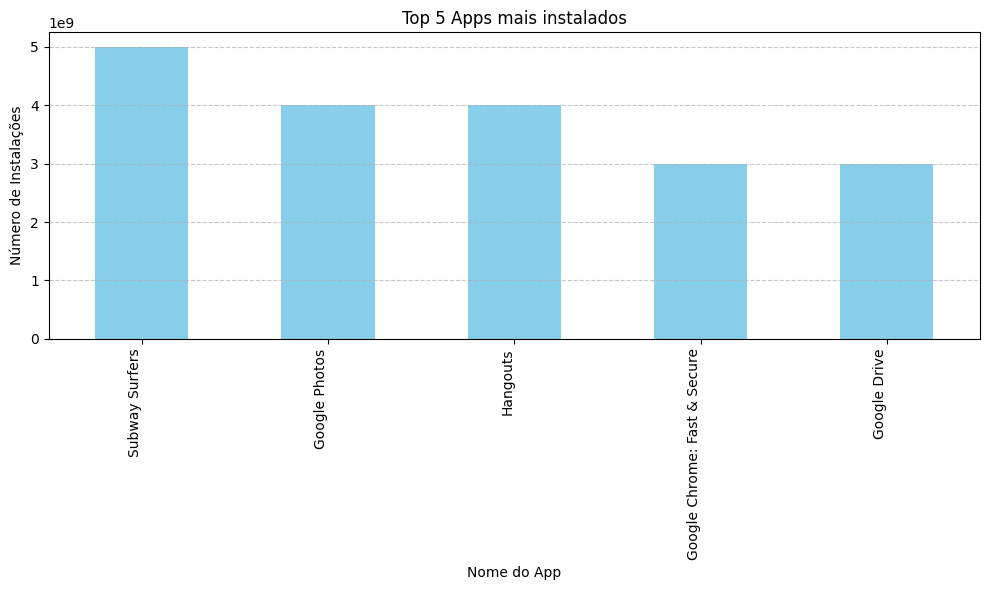

In [248]:
coluna_instalacoes = linhas_unicas['Installs']
coluna_instalacoes = coluna_instalacoes.str.replace('+', '', regex=False)
coluna_instalacoes = coluna_instalacoes.str.replace(',', '', regex=False)
coluna_instalacoes = pd.to_numeric(coluna_instalacoes, errors='coerce')
coluna_instalacoes = coluna_instalacoes.fillna(0)
linhas_unicas['Installs'] = coluna_instalacoes

# soma as instalações por nome de APP
grupo_apps = linhas_unicas.groupby('App')['Installs'].sum()
# pega os 5 que tiveram mais instalações
top_5 = grupo_apps.nlargest(5)

print("\nTop 5 aplicativos mais instalados:")
print(top_5)

plt.figure(figsize=(10, 6))
top_5.plot(kind='bar', color='skyblue')

plt.title('Top 5 Apps mais instalados')
plt.xlabel('Nome do App')
plt.ylabel('Número de Instalações')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Categorias de Apps (Gráfico de Pizza):


15 Categorias
Category
FAMILY                1943
GAME                  1121
TOOLS                  843
BUSINESS               427
MEDICAL                408
PRODUCTIVITY           407
PERSONALIZATION        388
LIFESTYLE              373
COMMUNICATION          366
FINANCE                360
SPORTS                 351
PHOTOGRAPHY            322
HEALTH_AND_FITNESS     306
SOCIAL                 280
NEWS_AND_MAGAZINES     264
OTHERS                2199
Name: count, dtype: int64


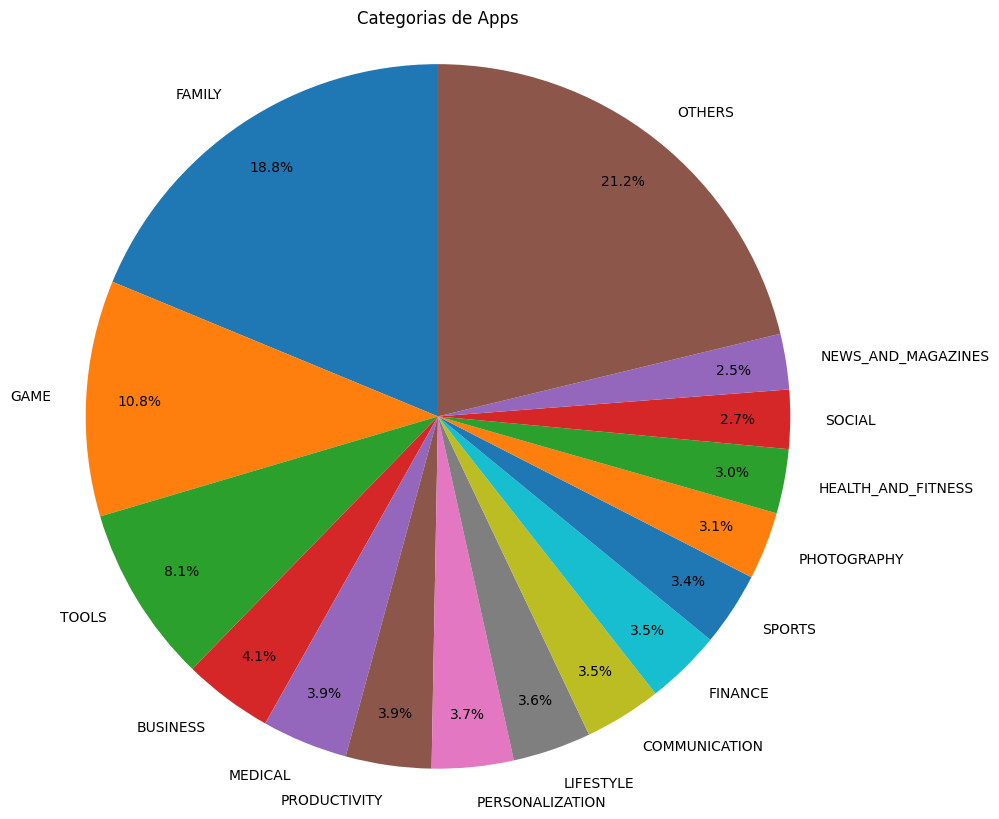

In [249]:
# conta quantos apps tem em cada categoria
categorias = linhas_unicas['Category'].value_counts()

# separa as categorias mais comuns
limite = 15
mais_comuns = categorias.nlargest(limite)

# separa as categorias restantes
outras = categorias.iloc[limite:].sum()

# transforma essas categorias em "OTHERS"
if outras > 0:
    mais_comuns['OTHERS'] = outras

print("\n15 Categorias")
print(mais_comuns)

plt.figure(figsize=(10, 10))
plt.pie(
    mais_comuns,                         
    labels=mais_comuns.index,            
    autopct='%1.1f%%',                   # mostra porcentagem (1 casa decimal)
    startangle=90,                       # começa de cima
    pctdistance=0.85                     # distância do número pra borda
)

plt.title('Categorias de Apps')
plt.axis('equal')
plt.show()


O App Mais Caro do Dataset:

In [ ]:

linhas_unicas['Price'] = linhas_unicas['Price'].str.replace('$', '', regex=False)
linhas_unicas['Price'] = pd.to_numeric(linhas_unicas['Price'], errors='coerce')
linhas_unicas['Price'] = linhas_unicas['Price'].fillna(0)

# encontra a linha onde está o maior valor da coluna 'Price'
linha_mais_caro = linhas_unicas['Price'].idxmax()

# pega o nome e o preço do app nessa linha
app_caro = linhas_unicas.loc[linha_mais_caro, ['App', 'Price']]

print("\nApp mais caro:")
print("Nome:", app_caro['App'])
print(f"Preço: ${app_caro['Price']:.2f}")


App mais caro:
Nome: I'm Rich - Trump Edition
Preço: $400.00


C:\Users\twvin\AppData\Local\Temp\ipykernel_17504\808922563.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linhas_unicas['Price'] = linhas_unicas['Price'].str.replace('$', '', regex=False)
C:\Users\twvin\AppData\Local\Temp\ipykernel_17504\808922563.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linhas_unicas['Price'] = pd.to_numeric(linhas_unicas['Price'], errors='coerce')
C:\Users\twvin\AppData\Local\Temp\ipykernel_17504\808922563.py:3: SettingWithCopyWarning: 
A value is trying to be set on a co

Nº de Aplicativos Para Maiores de 17 Anos:

In [251]:
# Filtra a tabela para pegar só os apps com classificação 'Mature 17+'
apps_maiores = linhas_unicas[linhas_unicas['Content Rating'] == 'Mature 17+']

# Conta quantos apps foram encontrados
quantidade = len(apps_maiores)

# Mostra o resultado no terminal
print("\nQuantidade de apps com classificação 'Mature 17+':", quantidade)


Quantidade de apps com classificação 'Mature 17+': 447


10 Apps Melhores Avaliados:

In [252]:
# Substitui valores vazios (NaN) por 0
linhas_unicas['Rating'] = linhas_unicas['Rating'].fillna(0)
linhas_unicas.loc[linhas_unicas['Rating'] > 5.0, 'Rating'] = 0 # seleciona linhas e colunas e garante que as avaliações não vão ser maiores que 5.0

# Ordena os apps pelo número de reviews, do maior pro menor
ordenados = linhas_unicas.sort_values(by='Rating', ascending=False)

top_reviews = ordenados.head(10)

# Mostra os nomes e a quantidade de reviews
print("\nTop 10 apps com mais avaliações:")
print(top_reviews[['App', 'Rating']])


Top 10 apps com mais avaliações:
                                                     App  Rating
8417                                        D-H Pharmacy     5.0
8411                                              DH-UFO     5.0
8335                                       DF Glue Board     5.0
8327                 The Divine Feminine App: the DF App     5.0
6275                                              BI APP     5.0
6272                                       Propel BI APP     5.0
6171                                            BG Guide     5.0
9536   Shabad Gurubani Punjabi mp3 free - Ek Onkar Sa...     5.0
10820                                    Fr. Daoud Lamei     5.0
8395                                               DG TV     5.0


C:\Users\twvin\AppData\Local\Temp\ipykernel_17504\1676935505.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linhas_unicas['Rating'] = linhas_unicas['Rating'].fillna(0)


2 Cálculos Sobre o Dataset (Uma lista e um valor único):

In [253]:
# Apps com menor avaliação
menor_review = linhas_unicas.sort_values(by='Rating').head(5)[['App', 'Rating']]
lista_menor_review = menor_review.values.tolist() 

print("5 apps com menor avaliação (lista):")
print(lista_menor_review)

# Média do valor dos apps pagos
apps_pagos = linhas_unicas[linhas_unicas['Price'] > 0]
media_precos = apps_pagos['Price'].mean()

print(f"\nMédia do valor dos apps pagos: ${media_precos:.2f}")

5 apps com menor avaliação (lista):
[['FieldBi FR Offline', 0.0], ['Parkinson Exercices FR', 0.0], ['payermonstationnement.fr', 0.0], ['Gold Quote - Gold.fr', 0.0], ['Poop FR', 0.0]]

Média do valor dos apps pagos: $13.96


2 Novos Gráficos (Gráfico de Linha e Histograma)

Dados para o gráfico de linhas (Top 10 Categorias por Preço Médio):
Category
FINANCE                8.057861
LIFESTYLE              6.329410
MEDICAL                2.501691
EVENTS                 1.718594
FAMILY                 1.245919
PRODUCTIVITY           0.616536
BOOKS_AND_REFERENCE    0.520739
BUSINESS               0.410515
WEATHER                0.395366
PERSONALIZATION        0.390387
Name: Price, dtype: float64


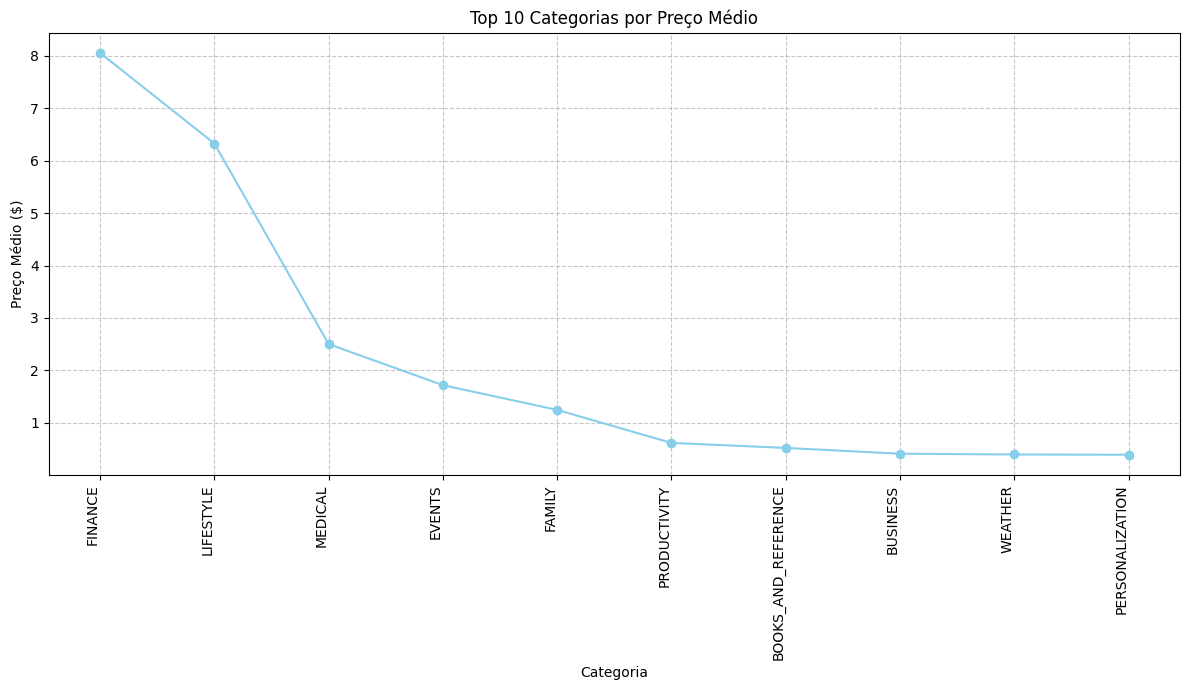

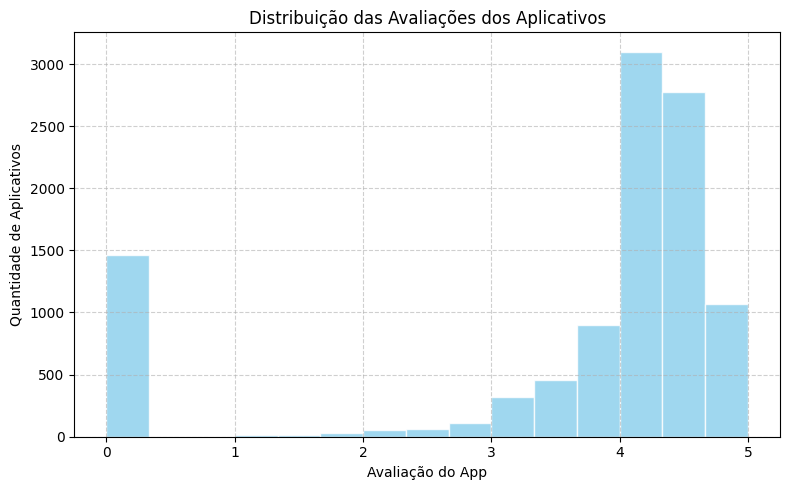

In [254]:
# Media de Preço por Categoria
media_preco_categoria = linhas_unicas.groupby('Category')['Price'].mean().nlargest(10)

print("Dados para o gráfico de linhas (Top 10 Categorias por Preço Médio):")
print(media_preco_categoria)
plt.figure(figsize=(12, 7))
# 'marker='o'' coloca um círculo em cada ponto para facilitar a visualização.
# 'linestyle='-'' garante uma linha contínua.
plt.plot(media_preco_categoria.index, media_preco_categoria.values, marker='o', linestyle='-', color='skyblue')
plt.title('Top 10 Categorias por Preço Médio')
plt.xlabel('Categoria')
plt.ylabel('Preço Médio ($)')
plt.xticks(rotation=90, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # ajusta o layout
plt.show()

# Histograma sobre a Avaliação dos Apps

avaliacao= linhas_unicas['Rating'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(avaliacao, bins=15, color='skyblue', edgecolor='white', alpha=0.8)
plt.title('Distribuição das Avaliações dos Aplicativos')
plt.xlabel('Avaliação do App')
plt.ylabel('Quantidade de Aplicativos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()